In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [2]:
df = pd.read_csv('data/processed/fraud_data_with_country.csv')
print("Shape:", df.shape)
df.head()

Shape: (151112, 15)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,lower_bound_ip_address,upper_bound_ip_address,country
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0,0,NaN,NaN,Unknown
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0,0,NaN,NaN,Unknown
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1,0,NaN,NaN,Unknown
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0,0,NaN,NaN,Unknown
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0,0,NaN,NaN,Unknown


In [3]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

# time_since_signup in hours
df['time_since_signup'] = (df['purchase_time'] - df['signup_time']).dt.total_seconds() / 3600

# hour of day and day of week
df['hour_of_day'] = df['purchase_time'].dt.hour
df['day_of_week'] = df['purchase_time'].dt.dayofweek

print("Time features created")
print(df[['time_since_signup', 'hour_of_day', 'day_of_week']].describe())

Time features created
       time_since_signup    hour_of_day    day_of_week
count      151112.000000  151112.000000  151112.000000
mean         1370.008125      11.521593       3.011819
std           868.406422       6.912474       2.006203
min             0.000278       0.000000       0.000000
25%           607.431528       6.000000       1.000000
50%          1368.429306      12.000000       3.000000
75%          2123.479028      17.000000       5.000000
max          2879.992222      23.000000       6.000000


In [4]:
# Transaction frequency per user
df = df.sort_values('purchase_time')
df['user_transaction_count'] = df.groupby('user_id')['user_id'].transform('count')

# Transaction velocity - number of transactions per user per day
df['purchase_date'] = df['purchase_time'].dt.date
df['user_daily_transactions'] = df.groupby(['user_id', 'purchase_date'])['user_id'].transform('count')

print("Velocity features created")
print(df[['user_transaction_count', 'user_daily_transactions']].describe())

Velocity features created
       user_transaction_count  user_daily_transactions
count                151112.0                 151112.0
mean                      1.0                      1.0
std                       0.0                      0.0
min                       1.0                      1.0
25%                       1.0                      1.0
50%                       1.0                      1.0
75%                       1.0                      1.0
max                       1.0                      1.0


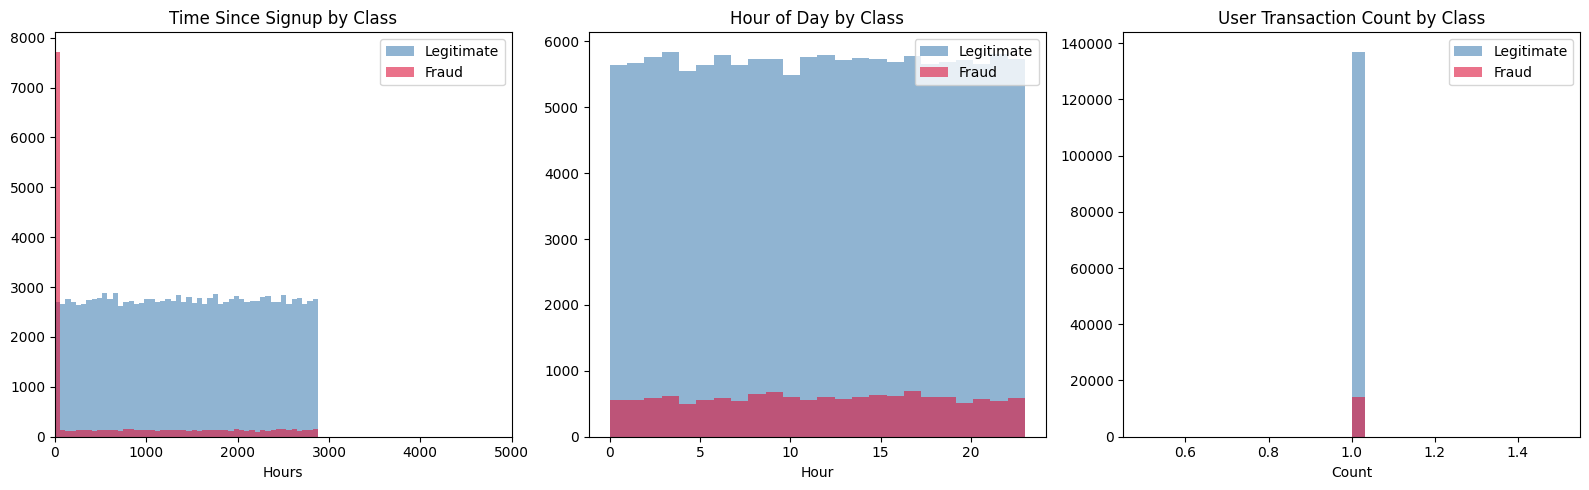

In [5]:
# Plot new features vs fraud
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df[df['class']==0]['time_since_signup'], bins=50, alpha=0.6, color='steelblue', label='Legitimate')
axes[0].hist(df[df['class']==1]['time_since_signup'], bins=50, alpha=0.6, color='crimson', label='Fraud')
axes[0].set_title('Time Since Signup by Class')
axes[0].set_xlabel('Hours')
axes[0].set_xlim(0, 5000)
axes[0].legend()

axes[1].hist(df[df['class']==0]['hour_of_day'], bins=24, alpha=0.6, color='steelblue', label='Legitimate')
axes[1].hist(df[df['class']==1]['hour_of_day'], bins=24, alpha=0.6, color='crimson', label='Fraud')
axes[1].set_title('Hour of Day by Class')
axes[1].set_xlabel('Hour')
axes[1].legend()

axes[2].hist(df[df['class']==0]['user_transaction_count'], bins=30, alpha=0.6, color='steelblue', label='Legitimate')
axes[2].hist(df[df['class']==1]['user_transaction_count'], bins=30, alpha=0.6, color='crimson', label='Fraud')
axes[2].set_title('User Transaction Count by Class')
axes[2].set_xlabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('data/processed/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

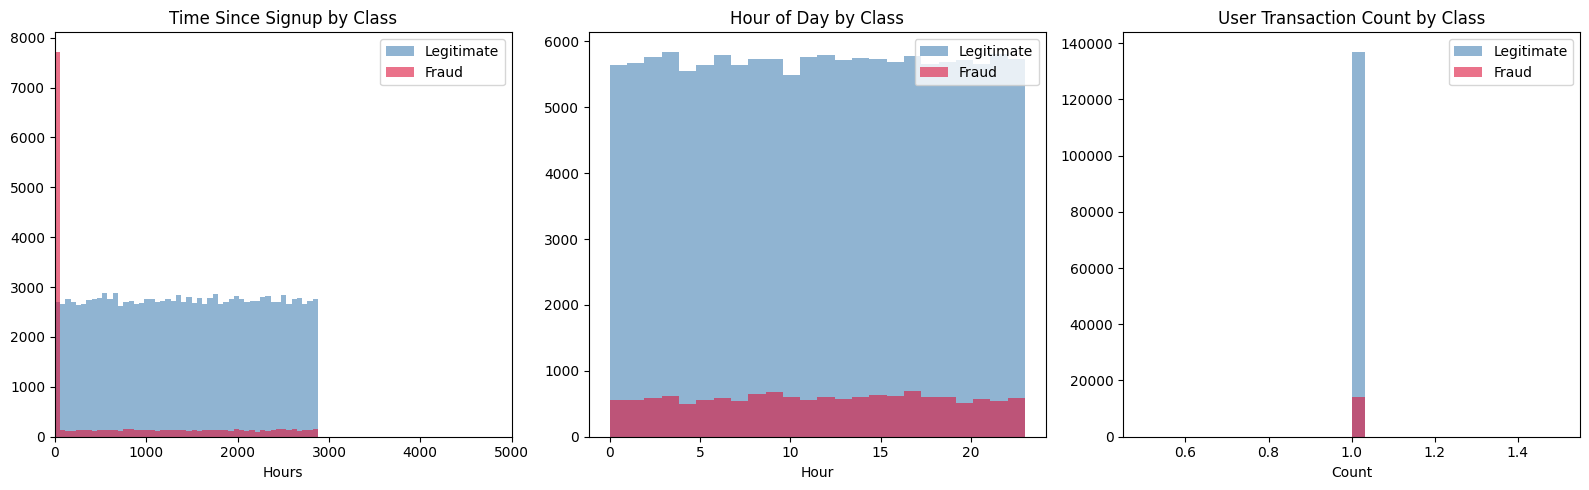

In [6]:
# Plot new features vs fraud
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df[df['class']==0]['time_since_signup'], bins=50, alpha=0.6, color='steelblue', label='Legitimate')
axes[0].hist(df[df['class']==1]['time_since_signup'], bins=50, alpha=0.6, color='crimson', label='Fraud')
axes[0].set_title('Time Since Signup by Class')
axes[0].set_xlabel('Hours')
axes[0].set_xlim(0, 5000)
axes[0].legend()

axes[1].hist(df[df['class']==0]['hour_of_day'], bins=24, alpha=0.6, color='steelblue', label='Legitimate')
axes[1].hist(df[df['class']==1]['hour_of_day'], bins=24, alpha=0.6, color='crimson', label='Fraud')
axes[1].set_title('Hour of Day by Class')
axes[1].set_xlabel('Hour')
axes[1].legend()

axes[2].hist(df[df['class']==0]['user_transaction_count'], bins=30, alpha=0.6, color='steelblue', label='Legitimate')
axes[2].hist(df[df['class']==1]['user_transaction_count'], bins=30, alpha=0.6, color='crimson', label='Fraud')
axes[2].set_title('User Transaction Count by Class')
axes[2].set_xlabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('data/processed/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Drop columns we don't need for modeling
drop_cols = ['user_id', 'signup_time', 'purchase_time', 'device_id', 
             'ip_address', 'ip_int', 'lower_bound_ip_address', 
             'upper_bound_ip_address', 'purchase_date']

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("Remaining columns:", df_model.columns.tolist())

Remaining columns: ['purchase_value', 'source', 'browser', 'sex', 'age', 'class', 'country', 'time_since_signup', 'hour_of_day', 'day_of_week', 'user_transaction_count', 'user_daily_transactions']


In [8]:
# One-hot encode categorical columns
cat_cols = ['source', 'browser', 'sex', 'country']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print("After encoding shape:", df_model.shape)
print(df_model.dtypes.value_counts())

After encoding shape: (151112, 15)
bool       7
int64      5
int32      2
float64    1
Name: count, dtype: int64


In [9]:
# Separate features and target
X = df_model.drop('class', axis=1)
y = df_model['class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

X shape: (151112, 14)
y shape: (151112,)

Class distribution:
class
0    136961
1     14151
Name: count, dtype: int64


In [10]:
# Stratified train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts())

Train size: (120889, 14)
Test size: (30223, 14)

Train class distribution:
class
0    109568
1     11321
Name: count, dtype: int64


In [11]:
# Scale numerical features
scaler = StandardScaler()
num_cols = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 
            'day_of_week', 'user_transaction_count', 'user_daily_transactions']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Scaling done")

Scaling done


Before SMOTE:
class
0    109568
1     11321
Name: count, dtype: int64

After SMOTE:
class
0    109568
1    109568
Name: count, dtype: int64


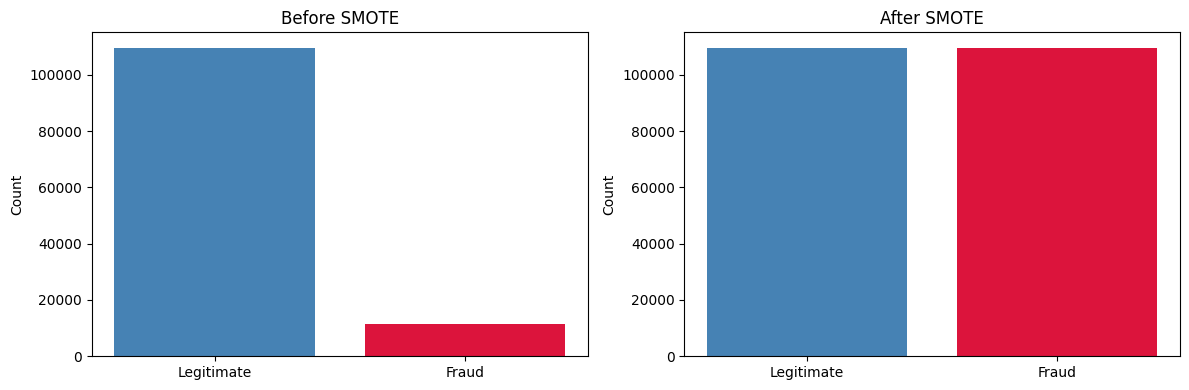

In [12]:
# Apply SMOTE on training set only
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Legitimate', 'Fraud'], y_train.value_counts().values, color=['steelblue', 'crimson'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

axes[1].bar(['Legitimate', 'Fraud'], pd.Series(y_train_smote).value_counts().values, color=['steelblue', 'crimson'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data/processed/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Save processed data
import pickle

X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote_df = pd.Series(y_train_smote, name='class')

X_train_smote_df.to_csv('data/processed/X_train_fraud.csv', index=False)
y_train_smote_df.to_csv('data/processed/y_train_fraud.csv', index=False)
X_test.to_csv('data/processed/X_test_fraud.csv', index=False)
y_test.to_csv('data/processed/y_test_fraud.csv', index=False)

with open('models/scaler_fraud.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("All processed data saved!")
print("X_train after SMOTE:", X_train_smote_df.shape)
print("X_test:", X_test.shape)

All processed data saved!
X_train after SMOTE: (219136, 14)
X_test: (30223, 14)
